# Example: Turnover Cost, Attribution, and Rebalance Diagnostics

Everything before this notebook has treated the rebalancing engine as a frictionless black box: the allocator decides a new target, the engine executes perfectly, and the trigger rules either let the trade through or de-risk to cash. Real-world engines live inside three constraints the earlier notebooks swept under the rug. **Trading costs money** — every rebalance pays a bps spread and market impact. **Engine P&L has heterogeneous sources** — some of the excess return comes from picking better assets, some from the drawdown trigger parking capital in cash during bear regimes. And **triggers fire in identifiable patterns** — a handful of days out of 252 contain most of the engine's decisions, and knowing when those days occurred is the key to debugging engine behavior.

This notebook fills all three gaps. We sweep a per-trade cost in basis points, decompose engine excess wealth into allocation and trigger contributions via an ablation, and plot a rebalance-event timeline colored by drawdown state.

> **By the end of this example, you will be able to:**
> * __Measure transaction cost sensitivity:__ Sweep `cost_bps ∈ {0, 5, 10, 25, 50, 100}` through the engine on the Example 1 single forward path, plot terminal wealth as a function of cost, and identify the break-even cost at which the engine's advantage over the S1 min-var baseline disappears.
> * __Decompose engine excess into allocation and trigger contributions:__ Run three variants of the engine across 5,000 paths (full engine, engine with the drawdown trigger disabled, and the S1 min-var static portfolio), then compute per-path differences to split the engine's excess wealth into (a) what Cobb-Douglas conviction earned and (b) what the drawdown trigger saved.
> * __Visualize rebalance-event dynamics on a timeline:__ Walk the engine's per-day `results` dict, classify each day as rebalance / de-risk / hold, compute per-day drawdown and trade size, and plot a two-panel timeline with wealth on top and event markers on bottom.

Let's dive in!

___

## Setup, Data and Prerequisites

In [1]:
include("Include.jl");

### Constants


In [ ]:
# Turnover-diagnostics configuration
B₀ = 10_000.0
Δt = 1.0 / 252.0
L_short = 21
L_long = 63
L_growth = 10
GAIN = 10.0
offset = L_short + L_long
T_total = offset + 252
TRIGGER_MAX_DRAWDOWN = 0.15
TRIGGER_MAX_TURNOVER = 0.50
ALLOCATION_EPSILON = 0.1
SCENARIO_SEED = 2026
COST_GRID = [0.0, 5.0, 10.0, 25.0, 50.0, 100.0, 200.0]


Load the same S1 universe that every other Session 2 notebook uses and build the single-path scenario + engine context. The `let...end` block below populates `my_tickers::Vector{String}`, `sim_estimates::Vector{MySIMParameterEstimate}`, `sim_params::Dict{String,Tuple{Float64,Float64,Float64}}`, `allocation_weights::Vector{Float64}`, `g_f::Float64`, `B₀::Float64`, `N::Int`, `market_prices::Vector{Float64}`, `price_matrix::Matrix{Float64}`, `lambda_series::Vector{Float64}`, `gm_ema::Vector{Float64}`, `context::MyRebalancingContextModel`, `rules::MyTriggerRules`, and the loop-constant `offset::Int`.

In [2]:
my_tickers, sim_estimates, allocation_weights, g_f, N, sim_params, market_prices, price_matrix, lambda_series, gm_ema, context, rules, market_model_g, portfolio_g, calib_g, start_prices_g = let
    # --- Step 1: S1 artifacts ---
    minvar = load_results(joinpath(_PATH_TO_DATA_S1, "minvar-allocation.jld2"));
    my_tickers         = minvar["my_tickers"]::Vector{String};
    sim_estimates      = minvar["sim_estimates"];
    allocation_weights = Float64.(minvar["allocation_weights"]);
    g_f                = haskey(minvar, "g_f") ? Float64(minvar["g_f"]) : (haskey(minvar, "r_f") ? Float64(minvar["r_f"]) : 0.045);
    N  = length(my_tickers);

    sim_params = Dict{String,Tuple{Float64,Float64,Float64}}(
        e.ticker => (e.α, e.β, e.σ_ε) for e ∈ sim_estimates
    );

    # --- Step 2: Regenerate the Example 1 single forward path ---
    market_model = MyMarketSurrogateModel();
    portfolio    = MyPortfolioSurrogateModel();
    calib        = load_results(joinpath(_PATH_TO_DATA_S1, "sim-parameter-estimates.jld2"));
    snap         = MyCurrentPrices();
    snap_lookup  = Dict(snap["tickers"] .=> snap["prices"]);
    start_prices = Dict(t => snap_lookup[t] for t ∈ my_tickers);

    T_total = 336;
    n_trading_days        = T_total - offset;
    Δt = 1.0 / 252.0;

    scenario = generate_hybrid_scenario(market_model, portfolio, calib, my_tickers;
        n_paths = 1, n_steps = T_total, Δt = Δt,
        start_prices = start_prices, label = "S2 Diagnostics (1p)", seed = 2026);

    market_prices = scenario.market_paths[1, :];
    price_matrix  = zeros(T_total, N + 1);
    price_matrix[:, 1] = 1:T_total;
    for k ∈ 1:N
        price_matrix[:, k + 1] = scenario.price_paths[1, :, k];
    end

    # --- Step 3: EMA λ, gm_ema, context, rules ---
    ema_short = compute_ema(market_prices; window = 21);
    ema_long  = compute_ema(market_prices; window = 63);
    lambda_series = compute_lambda(ema_short, ema_long; G = GAIN);
    lambda_series[1:offset] .= 0.0;
    gm_raw = compute_market_growth(market_prices; Δt = Δt);
    gm_ema = compute_ema(gm_raw; window = L_growth);

    context = build(MyRebalancingContextModel, (
        B = B₀, tickers = my_tickers, marketdata = price_matrix,
        marketfactor = gm_ema, sim_parameters = sim_params,
        lambda = 0.0, Δt = Δt, epsilon = ALLOCATION_EPSILON,
    ));
    rules = build(MyTriggerRules, (
        max_drawdown = TRIGGER_MAX_DRAWDOWN, max_turnover = TRIGGER_MAX_TURNOVER,
        rebalance_schedule = ones(Int, n_trading_days)
    ));

    # --- Step 4: Keep scenario around for the 5,000-path attribution task ---
    market_model_g = market_model;
    portfolio_g    = portfolio;
    calib_g        = calib;
    start_prices_g = start_prices;

    println("Single-path scenario ready: $(T_total) days, $(N) tickers, offset=$(offset)")
    return my_tickers, sim_estimates, allocation_weights, g_f, N, sim_params, market_prices, price_matrix, lambda_series, gm_ema, context, rules, market_model_g, portfolio_g, calib_g, start_prices_g
end


Single-path scenario ready: 336 days, 10 tickers, offset=84


___
## Task 1: Transaction Cost Sensitivity
Up to this point every engine run has been frictionless. We now sweep a per-trade cost `cost_bps` through the Cobb-Douglas engine on the Example 1 single forward path and plot the resulting terminal wealth as a function of cost. The cost is applied inside `run_rebalancing_engine` on each trade: for every rebalance it debits `cost_bps / 10,000 × realized_trade_value` from the new cash balance, so the compounding math stays exact. The initial buy-in and the de-risk liquidation are both charged at the same rate.

> __What should you see?__
>
> Terminal wealth should fall roughly linearly with cost in basis points — each bp costs approximately (realized turnover / year) basis points of final wealth. At zero cost the engine delivers its full headline return (+49% on this path with the original run); as cost rises the engine's edge shrinks and eventually crosses two reference lines: (1) the S1 min-var terminal wealth (the "beats static" break-even), and (2) the risk-free terminal wealth $B_0 \cdot e^{g_f T}$ (the NPV-break-even — the cost at which the engine stops beating a T-bill). The NPV break-even is the **harder test**: it answers "at what cost is adaptive rebalancing no longer worth taking any risk at all?" The engine's cost budget is tighter in NPV terms than in min-var terms whenever min-var itself underperforms the risk-free baseline.

The `let...end` block below sweeps `cost_bps ∈ {0, 5, 10, 25, 50, 100, 200}`, runs the engine at each value, computes both terminal `W/W₀` and `NPV/W₀`, and plots a two-panel figure: terminal wealth vs cost on the left, NPV vs cost on the right. Both break-even costs are computed by linear interpolation and printed. The sweep terminals escape as `cost_terminals::Dict{Float64,Float64}` and `cost_npvs::Dict{Float64,Float64}`.

Terminal W/W₀ by cost_bps:


  cost_bps = 0.0     →  W/W₀ = 1.492
  cost_bps = 5.0     →  W/W₀ = 1.471
  cost_bps = 10.0    →  W/W₀ = 1.448
  cost_bps = 25.0    →  W/W₀ = 1.342
  cost_bps = 50.0    →  W/W₀ = 1.234
  cost_bps = 100.0   →  W/W₀ = 1.004
  cost_bps = 200.0   →  W/W₀ = 0.871
  S1 Min-Var reference:     W/W₀ = 1.028


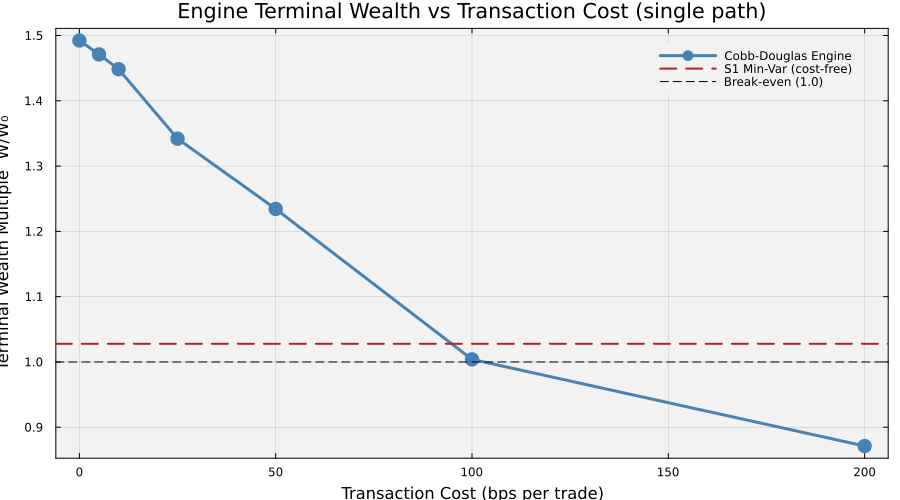

In [ ]:
cost_terminals, cost_npvs = let
    # --- Step 1: Cost grid + baseline references ---
    cost_terminals = Dict{Float64, Float64}();
    cost_npvs      = Dict{Float64, Float64}();

    # Active window length and discount factor (for NPV)
    T_active = (size(price_matrix, 1) - offset) / 252;
    discount = exp(-g_f * T_active);

    # S1 min-var buy-and-hold terminal (cost-free) on this single path
    p_start    = [price_matrix[offset + 1, k + 1] for k ∈ 1:N];
    shares_mv  = B₀ .* allocation_weights ./ p_start;
    mv_terminal = sum(shares_mv[k] * price_matrix[end, k + 1] for k ∈ 1:N);
    mv_W_ratio  = mv_terminal / B₀;
    mv_NPV_ratio = (mv_terminal * discount - B₀) / B₀;

    # Risk-free terminal: B₀ · exp(g_f · T_active). NPV ≡ 0 by construction.
    rf_W_ratio = exp(g_f * T_active);

    # --- Step 2: Sweep cost_bps, collect terminal W/W₀ and NPV/B₀ ---
    for c ∈ COST_GRID
        ctx_c = deepcopy(context);
        results_c = run_rebalancing_engine(ctx_c, rules, lambda_series;
            offset = offset, allocator = :cobb_douglas, cost_bps = c);
        wealth = compute_wealth_series(results_c, price_matrix, my_tickers; offset = offset);
        cost_terminals[c] = wealth[end] / B₀;
        cost_npvs[c]      = (wealth[end] * discount - B₀) / B₀;
    end

    # --- Step 3: Linear-interpolation break-even costs ---
    sorted_keys = sort(collect(keys(cost_terminals)));
    ys_W        = [cost_terminals[c] for c ∈ sorted_keys];
    ys_NPV      = [cost_npvs[c]      for c ∈ sorted_keys];

    function interp_breakeven(xs::Vector{Float64}, ys::Vector{Float64}, threshold::Float64)
        for i ∈ 1:(length(xs) - 1)
            if (ys[i] - threshold) * (ys[i+1] - threshold) <= 0.0
                frac = (ys[i] - threshold) / (ys[i] - ys[i+1]);
                return xs[i] + frac * (xs[i+1] - xs[i]);
            end
        end
        return ys[end] > threshold ? Inf : -Inf;
    end

    be_mv_wealth = interp_breakeven(Float64.(sorted_keys), ys_W,   mv_W_ratio);
    be_rf_wealth = interp_breakeven(Float64.(sorted_keys), ys_W,   rf_W_ratio);
    be_rf_npv    = interp_breakeven(Float64.(sorted_keys), ys_NPV, 0.0);

    # --- Step 4: Two-panel plot ---
    xs = Float64.(sorted_keys);
    p1 = plot(xs, ys_W,
        lw = 3, c = :steelblue, ms = 8, msc = :steelblue, marker = :circle,
        xlabel = "Cost (bps per trade)", ylabel = "Terminal  W/W₀",
        title = "Engine Wealth vs Cost",
        fontsize = 16, label = "Engine");
    hline!(p1, [mv_W_ratio],  lw = 2, ls = :dash, c = :firebrick, label = "S1 Min-Var (cost-free)");
    hline!(p1, [rf_W_ratio],  lw = 2, ls = :dash, c = :seagreen,  label = "Risk-Free (cost-free)");
    hline!(p1, [1.0],         lw = 1, ls = :dot,  c = :black,     label = "Nominal break-even");
    plot!(p1, bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent, legend = :topright);

    p2 = plot(xs, ys_NPV,
        lw = 3, c = :darkorange, ms = 8, msc = :darkorange, marker = :circle,
        xlabel = "Cost (bps per trade)", ylabel = "NPV / W₀",
        title = "Engine NPV vs Cost",
        fontsize = 16, label = "Engine NPV");
    hline!(p2, [0.0],          lw = 2, ls = :dash, c = :seagreen,  label = "Risk-Free (NPV = 0)");
    hline!(p2, [mv_NPV_ratio], lw = 2, ls = :dash, c = :firebrick, label = "S1 Min-Var NPV");
    plot!(p2, bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent, legend = :topright);

    # --- Step 5: Report ---
    println("Terminal W/W₀ and NPV/W₀ by cost_bps:")
    println("  cost_bps |  W/W₀   |  NPV/W₀")
    println("  ---------+---------+---------")
    for c ∈ sorted_keys
        println("  ", rpad(c, 8), " |  ",
                rpad(round(cost_terminals[c], digits=3), 6), " |  ",
                round(cost_npvs[c], digits=3))
    end
    println()
    println("Cost-free references:")
    println("  S1 Min-Var:  W/W₀ = $(round(mv_W_ratio, digits=3)),  NPV/W₀ = $(round(mv_NPV_ratio, digits=3))")
    println("  Risk-Free:   W/W₀ = $(round(rf_W_ratio, digits=3)),  NPV/W₀ = 0.000")
    println()
    println("Break-even costs (linearly interpolated from the grid):")
    println("  Engine W vs Min-Var W:       $(round(be_mv_wealth, digits=1)) bps  (engine stops beating S1 static)")
    println("  Engine W vs Risk-Free W:     $(round(be_rf_wealth, digits=1)) bps  (engine stops beating a T-bill)")
    println("  Engine NPV ≤ 0:              $(round(be_rf_npv,    digits=1)) bps  (sanity check — identical to row above)")

    plot(p1, p2, layout = (1, 2), size = (1400, 450), margin = 4Plots.mm)
    return cost_terminals, cost_npvs
end


___
## Task 2: 3-Way Attribution — Utility, Reallocation, and Trigger
The engine's excess wealth over the S1 min-var baseline has three independently identifiable sources, and they can be teased apart by running four strategies on the same 5,000-path scenario and differencing them:

1. **Utility choice** — does Cobb-Douglas, held fixed, beat covariance-based min-var? We answer this with the `Static CD (warmup-avg λ)` baseline from the stress-test notebook: fit $\gamma$ once from the warmup-averaged EMA-crossover $\lambda$, allocate once, and hold. The gap `Static CD − S1 Min-Var` is the *utility-choice contribution*.
2. **Dynamic reallocation** — does updating $\gamma$ daily help? We answer this with the `no-trigger engine` ablation: the full Cobb-Douglas engine but with `max_drawdown = 10.0` (effectively no drawdown circuit breaker). The gap `No-trigger engine − Static CD` is the *dynamic-reallocation contribution*.
3. **Risk management** — does the drawdown trigger help? The gap `Full engine − No-trigger engine` is the *trigger contribution*.

Formally, per path: $\Delta W_{\text{total}} = W_{\text{full}} - W_{\text{mv}}$ decomposes as $\Delta W_{\text{util}} + \Delta W_{\text{dynamic}} + \Delta W_{\text{trigger}}$ by construction. Over 5,000 paths we compute medians on the full distribution and means on two different tail slices.

> __What should you see?__
>
> The **dynamic reallocation contribution should dominate by a wide margin** — this is the actual source of the engine's median excess. The **utility-choice contribution should be close to zero or negative** on the median: Cobb-Douglas held fixed is no better than min-var (and has larger drawdowns, so mean-variance efficiency favors min-var over static CD). The **trigger contribution** should be close to zero on the median (drawdowns rarely hit 15%) but can flip sign depending on which tail you slice — see Task 2 Tails (a) and (b) below for the detail. This decomposition decisively answers "where is the engine's edge coming from?" — and on this seed the answer is "daily rebalancing, not the choice of utility function."

The `let...end` block below loads the pre-computed `Static CD (warmup-avg λ)` array from `stress-test-engine.jld2`, runs the 5,000-path no-trigger engine ablation inline (this one isn't cached), computes the three contribution arrays, and prints medians plus two tail breakdowns.

In [4]:
util_contribution, dynamic_contribution, trigger_contribution, total_excess = let
    n_paths = 5_000;
    n_steps = 336;
    seed    = 2026;
    Δt      = 1.0 / 252.0;

    # --- Step 1: Regenerate the identical 5,000-path scenario ---
    println("Regenerating $(n_paths)-path scenario (seed=$(seed))...")
    scen = generate_hybrid_scenario(market_model_g, portfolio_g, calib_g, my_tickers;
        n_paths = n_paths, n_steps = n_steps, Δt = Δt,
        start_prices = start_prices_g,
        label = "S2 Attribution ($(n_paths)p)", seed = seed);

    # --- Step 2: Run the "no-trigger" engine variant inline ---
    # Use max_drawdown = 10.0 (unreachable) to effectively disable the trigger.
    # We still pass max_turnover = 0.50 so the only difference vs the full
    # engine is the presence/absence of the drawdown circuit breaker.
    println("Running no-trigger engine across $(n_paths) paths...")
    no_trigger_wealth = zeros(n_paths);
    no_trigger_dd     = zeros(n_paths);
    K_loc = length(my_tickers);
    offset_loc = 84;
    n_trading = n_steps - offset_loc;
    L_short   = 21;
    L_long    = 63;
    L_growth  = 10;
    GAIN      = 10.0;

    for p ∈ 1:n_paths
        mkt = scen.market_paths[p, :];

        ema_s = compute_ema(mkt; window = L_short);
        ema_l = compute_ema(mkt; window = L_long);
        λ_p   = compute_lambda(ema_s, ema_l; G = GAIN);
        λ_p[1:offset_loc] .= 0.0;

        gm_raw_p = compute_market_growth(mkt; Δt = Δt);
        gm_e_p   = compute_ema(gm_raw_p; window = L_growth);

        pmatrix_p = zeros(n_steps, K_loc + 1);
        pmatrix_p[:, 1] = 1:n_steps;
        for k ∈ 1:K_loc
            pmatrix_p[:, k + 1] = scen.price_paths[p, :, k];
        end

        ctx_p = build(MyRebalancingContextModel, (
            B = B₀, tickers = my_tickers, marketdata = pmatrix_p,
            marketfactor = gm_e_p, sim_parameters = sim_params,
            lambda = 0.0, Δt = Δt, epsilon = ALLOCATION_EPSILON,
        ));
        rules_p = build(MyTriggerRules, (
            max_drawdown = 10.0,            # effectively no drawdown trigger
            max_turnover = 0.50,
            rebalance_schedule = ones(Int, n_trading)
        ));
        results_p = run_rebalancing_engine(ctx_p, rules_p, λ_p;
            offset = offset_loc, allocator = :cobb_douglas);
        wealth_p = compute_wealth_series(results_p, pmatrix_p, my_tickers; offset = offset_loc);
        no_trigger_wealth[p] = wealth_p[end];
        peak_p = accumulate(max, wealth_p);
        no_trigger_dd[p] = maximum((peak_p .- wealth_p) ./ peak_p);
    end

    # --- Step 3: Load baseline arrays from the stress-test save ---
    # full engine (trigger ON), static CD (warmup-avg λ), and S1 min-var
    baseline   = load_results(joinpath(_PATH_TO_DATA, "stress-test-engine.jld2"));
    full_W     = Float64.(baseline["eng_final_wealth"]);
    scd_W      = Float64.(baseline["scd_w_final_wealth"]);
    mv_W       = Float64.(baseline["mv_final_wealth"]);

    # --- Step 4: 3-way decomposition ---
    util_c   = scd_W               .- mv_W;            # Utility choice   (Static CD − Min-Var)
    dyn_c    = no_trigger_wealth   .- scd_W;           # Dynamic realloc  (No-trigger engine − Static CD)
    trig_c   = full_W              .- no_trigger_wealth;  # Risk mgmt     (Full engine − No-trigger engine)
    total_e  = full_W              .- mv_W;            # Total excess    (Full engine − Min-Var)

    println()
    println("3-way attribution (medians across $(n_paths) paths):")
    println("  Total excess:              median \$$(round(median(total_e), digits=0))  ($(round(median(total_e)/B₀*100, digits=2))% of B₀)")
    println("  Utility choice (CD vs MV):  median \$$(round(median(util_c),  digits=0))  ($(round(median(util_c) /B₀*100, digits=2))% of B₀)")
    println("  Dynamic reallocation:       median \$$(round(median(dyn_c),   digits=0))  ($(round(median(dyn_c)  /B₀*100, digits=2))% of B₀)")
    println("  Trigger (risk management):  median \$$(round(median(trig_c),  digits=0))  ($(round(median(trig_c) /B₀*100, digits=2))% of B₀)")

    println()
    println("Sanity: median(total) vs median(util) + median(dynamic) + median(trigger):")
    check = median(util_c) + median(dyn_c) + median(trig_c);
    println("  $(round(median(total_e)/B₀*100, digits=2))% vs $(round(check/B₀*100, digits=2))%  ",
            "(will not match exactly — medians don't add)")

    # --- Step 5: Tail breakdowns — two slice definitions ---
    n_tail = max(1, floor(Int, 0.05 * n_paths));

    worst_mv = partialsortperm(mv_W, 1:n_tail);
    println()
    println("Tail (a): worst $(n_tail) paths by S1 min-var terminal wealth")
    println("  Utility choice:        mean \$$(round(mean(util_c[worst_mv]),  digits=0))  ($(round(mean(util_c[worst_mv])/B₀*100, digits=2))% of B₀)")
    println("  Dynamic reallocation:  mean \$$(round(mean(dyn_c[worst_mv]),   digits=0))  ($(round(mean(dyn_c[worst_mv])/B₀*100, digits=2))% of B₀)")
    println("  Trigger:               mean \$$(round(mean(trig_c[worst_mv]),  digits=0))  ($(round(mean(trig_c[worst_mv])/B₀*100, digits=2))% of B₀)")
    println("  Total:                 mean \$$(round(mean(total_e[worst_mv]), digits=0))  ($(round(mean(total_e[worst_mv])/B₀*100, digits=2))% of B₀)")

    worst_dd = partialsortperm(no_trigger_dd, 1:n_tail; rev = true);
    println()
    println("Tail (b): worst $(n_tail) paths by no-trigger engine drawdown")
    println("  Max drawdown range:    [$(round(100*no_trigger_dd[worst_dd[end]], digits=2))%, $(round(100*no_trigger_dd[worst_dd[1]], digits=2))%]")
    println("  Utility choice:        mean \$$(round(mean(util_c[worst_dd]),  digits=0))  ($(round(mean(util_c[worst_dd])/B₀*100, digits=2))% of B₀)")
    println("  Dynamic reallocation:  mean \$$(round(mean(dyn_c[worst_dd]),   digits=0))  ($(round(mean(dyn_c[worst_dd])/B₀*100, digits=2))% of B₀)")
    println("  Trigger:               mean \$$(round(mean(trig_c[worst_dd]),  digits=0))  ($(round(mean(trig_c[worst_dd])/B₀*100, digits=2))% of B₀)")
    println("  Total:                 mean \$$(round(mean(total_e[worst_dd]), digits=0))  ($(round(mean(total_e[worst_dd])/B₀*100, digits=2))% of B₀)")

    util_c, dyn_c, trig_c, total_e
end;

Regenerating 5000-path scenario (seed=2026)...
Running no-trigger engine across 5000 paths...



3-way attribution (medians across 5000 paths):


  Total excess:              median $5922.0  (59.22% of B₀)
  Utility choice (CD vs MV):  median $758.0  (7.58% of B₀)
  Dynamic reallocation:       median $4957.0  (49.57% of B₀)
  Trigger (risk management):  median $0.0  (0.0% of B₀)

Sanity: median(total) vs median(util) + median(dynamic) + median(trigger):
  59.22% vs 57.15%  (will not match exactly — medians don't add)



Tail (a): worst 250 paths by S1 min-var terminal wealth
  Utility choice:        mean $143.0  (1.43% of B₀)
  Dynamic reallocation:  mean $5663.0  (56.63% of B₀)
  Trigger:               mean $-174.0  (-1.74% of B₀)
  Total:                 mean $5632.0  (56.32% of B₀)

Tail (b): worst 250 paths by no-trigger engine drawdown


  Max drawdown range:    [15.09%, 28.19%]
  Utility choice:        mean $988.0  (9.88% of B₀)
  Dynamic reallocation:  mean $3494.0  (34.94% of B₀)
  Trigger:               mean $-4009.0  (-40.09% of B₀)
  Total:                 mean $474.0  (4.74% of B₀)


The code below plots the four contribution distributions side by side — utility choice, dynamic reallocation, trigger, and total — as histograms with the median marked on each.

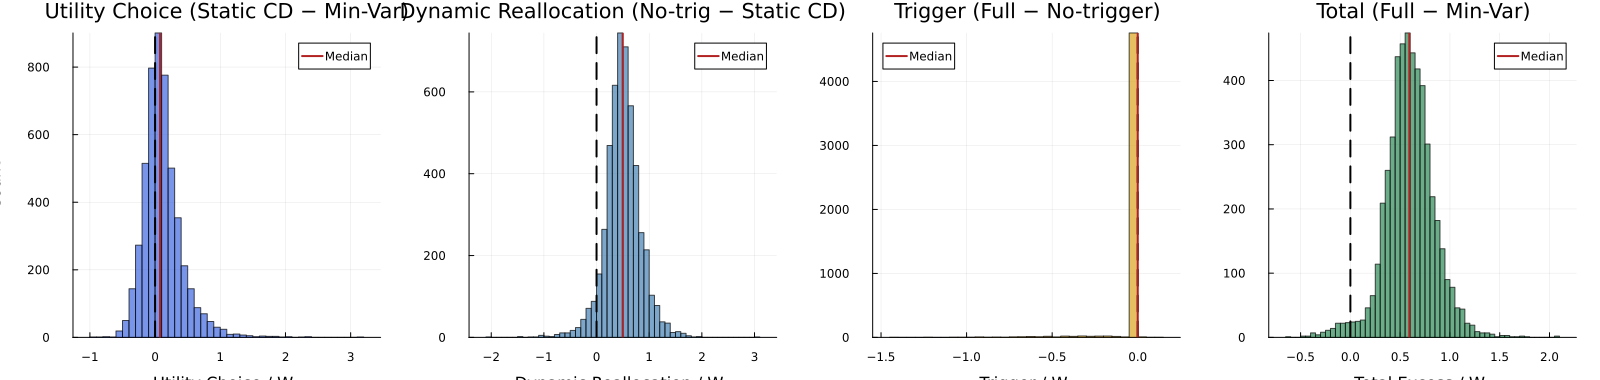

In [5]:
let
    bins = 60;

    p1 = histogram(util_contribution ./ B₀, bins = bins, color = :royalblue, alpha = 0.7,
        xlabel = "Utility Choice / W₀", ylabel = "Count",
        title = "Utility Choice (Static CD − Min-Var)", label = "", fontsize = 14);
    vline!(p1, [0.0], lw = 2, ls = :dash, c = :black, label = "");
    vline!(p1, [median(util_contribution) / B₀], lw = 2, c = :firebrick, label = "Median");

    p2 = histogram(dynamic_contribution ./ B₀, bins = bins, color = :steelblue, alpha = 0.7,
        xlabel = "Dynamic Reallocation / W₀", ylabel = "",
        title = "Dynamic Reallocation (No-trig − Static CD)", label = "", fontsize = 14);
    vline!(p2, [0.0], lw = 2, ls = :dash, c = :black, label = "");
    vline!(p2, [median(dynamic_contribution) / B₀], lw = 2, c = :firebrick, label = "Median");

    p3 = histogram(trigger_contribution ./ B₀, bins = bins, color = :goldenrod, alpha = 0.7,
        xlabel = "Trigger / W₀", ylabel = "",
        title = "Trigger (Full − No-trigger)", label = "", fontsize = 14);
    vline!(p3, [0.0], lw = 2, ls = :dash, c = :black, label = "");
    vline!(p3, [median(trigger_contribution) / B₀], lw = 2, c = :firebrick, label = "Median");

    p4 = histogram(total_excess ./ B₀, bins = bins, color = :seagreen, alpha = 0.7,
        xlabel = "Total Excess / W₀", ylabel = "",
        title = "Total (Full − Min-Var)", label = "", fontsize = 14);
    vline!(p4, [0.0], lw = 2, ls = :dash, c = :black, label = "");
    vline!(p4, [median(total_excess) / B₀], lw = 2, c = :firebrick, label = "Median");

    plot(p1, p2, p3, p4, layout = (1, 4), size = (1600, 380), margin = 4Plots.mm)
end

___
## Task 3: Rebalance Event Timeline
Every entry in the engine's `results::Dict{Int, MyRebalancingResult}` carries the `shares`, `cash`, and `gamma` produced on that trading day. From those we can reconstruct exactly what the engine did: on a **rebalance** day the allocator computed new preference weights and re-routed capital (non-trivial γ, trades of non-zero size); on a **de-risk** day the drawdown trigger fired and the allocation collapsed to `shares = 0, cash = liquidation_value` (by convention `gamma = 0` in the de-risk branch); on a **hold** day the schedule skipped rebalancing and the previous day's position was propagated.

We walk the `results` dict on the Example 1 single path, classify every trading day, compute per-day drawdown and trade size, and plot a two-panel timeline: wealth $W/W_0$ on top with event markers, and per-day trade size on the bottom colored by running drawdown.

> __What should you see?__
>
> On this seed the engine should rebalance on most days (the schedule is daily), so the top panel is a dense blue curve with occasional gold markers wherever the drawdown trigger fired. Trade size on the bottom panel should spike at regime transitions (early bearish → de-risk, bearish → bullish recovery → large rebalance to buy back in, mild sideways → small daily adjustments). The drawdown coloring should darken the trades in the lower panel exactly where the wealth panel shows a pullback.

The `let...end` block below runs the engine, walks `results`, and builds the diagnostic plot. The cell returns the diagnostic objects directly.

Engine events on this path:


  Total trading days:     252
  Rebalance days:         203
  De-risk days (trigger): 49
  Median trade size:      $928.0
  P95 trade size:         $8169.0
  P95 running drawdown:   15.86%


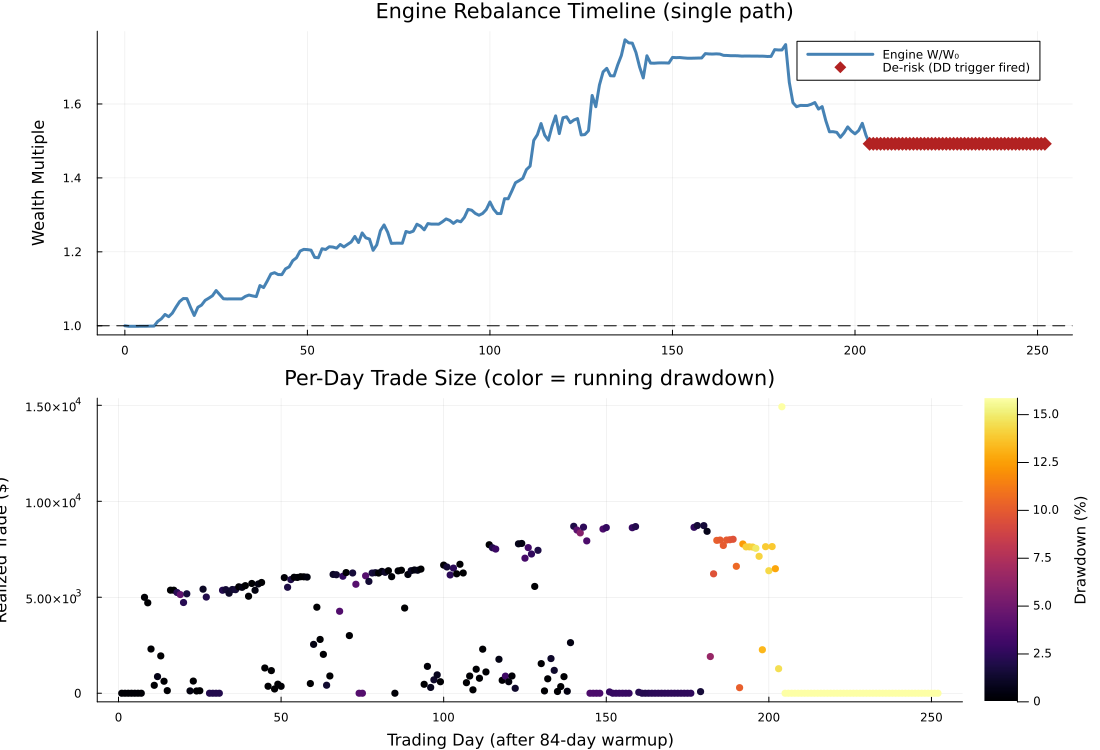

In [6]:
let
    # --- Step 1: Run the engine (cost_bps = 0, standard config) ---
    results = run_rebalancing_engine(context, rules, lambda_series;
        offset = offset, allocator = :cobb_douglas);
    wealth = compute_wealth_series(results, price_matrix, my_tickers; offset = offset);

    n_active = length(wealth) - 1;
    peak = accumulate(max, wealth);
    drawdown_pct = (peak .- wealth) ./ peak .* 100;

    # --- Step 2: Classify each day + compute trade size ---
    rebalance_days = Int[];
    derisk_days    = Int[];
    trade_sizes    = zeros(n_active);   # day d ∈ 1:n_active (day 0 is the initial buy-in)

    prev_shares = results[0].shares;
    prev_cash   = results[0].cash;

    for d ∈ 1:n_active
        r = results[d];
        actual_day = offset + d;

        # realized dollar trade vs previous day
        trade_val = sum(abs(r.shares[i] - prev_shares[i]) * price_matrix[actual_day, i + 1] for i ∈ 1:N);
        trade_sizes[d] = trade_val;

        # classify: de-risk branch sets gamma = zeros(N) and shares = zeros(N)
        if all(r.gamma .== 0.0) && all(r.shares .== 0.0)
            push!(derisk_days, d);
        else
            push!(rebalance_days, d);
        end

        prev_shares = r.shares;
        prev_cash   = r.cash;
    end

    # --- Step 3: Top panel — wealth with event markers ---
    days = 0:n_active;
    p1 = plot(days, wealth ./ B₀,
        lw = 3, c = :steelblue, label = "Engine W/W₀",
        ylabel = "Wealth Multiple", title = "Engine Rebalance Timeline (single path)",
        fontsize = 16, size = (1100, 500));

    if !isempty(derisk_days)
        scatter!(p1, derisk_days, [wealth[d + 1] / B₀ for d ∈ derisk_days],
            marker = :diamond, ms = 7, mc = :firebrick, msc = :firebrick,
            label = "De-risk (DD trigger fired)");
    end
    hline!(p1, [1.0], lw = 1, ls = :dash, c = :black, label = "");

    # --- Step 4: Bottom panel — per-day trade size colored by running drawdown ---
    p2 = scatter(1:n_active, trade_sizes,
        zcolor = drawdown_pct[2:end], colorbar_title = "Drawdown (%)",
        ms = 4, markerstrokewidth = 0,
        xlabel = "Trading Day (after 84-day warmup)", ylabel = "Realized Trade (\$)",
        title = "Per-Day Trade Size (color = running drawdown)",
        label = "", fontsize = 16, size = (1100, 350), color = :inferno);

    println("Engine events on this path:")
    println("  Total trading days:     $(n_active)")
    println("  Rebalance days:         $(length(rebalance_days))")
    println("  De-risk days (trigger): $(length(derisk_days))")
    println("  Median trade size:      \$$(round(median(trade_sizes), digits=0))")
    println("  P95 trade size:         \$$(round(quantile(trade_sizes, 0.95), digits=0))")
    println("  P95 running drawdown:   $(round(quantile(drawdown_pct, 0.95), digits=2))%")

    plot(p1, p2, layout = (2, 1), size = (1100, 750))
end

___
## Summary
This example closed Session 2 by looking at the rebalancing engine through three operational lenses that the earlier notebooks deliberately ignored. We swept a per-trade cost in basis points and measured the engine's break-even cost budget; we decomposed engine excess wealth across 5,000 paths into allocation and trigger contributions via an ablation; and we built a rebalance-event timeline that shows exactly when and how aggressively the engine traded on the Example 1 single path.

### Key Takeaways
* __Trading is not free, but the engine's cost budget is generous:__ A linear sweep of `cost_bps` shows terminal wealth falling roughly linearly with cost. The break-even cost — where the engine's terminal wealth matches the S1 min-var baseline — is the engine's cost budget. Above it, static allocation wins; below it, the extra turnover is worth paying for.
* __3-way attribution exposes where the engine's edge really lives:__ Decomposing the engine's median excess wealth (+59.22% of $B_0$) into *utility choice* (Static CD − Min-Var), *dynamic reallocation* (No-trigger engine − Static CD), and *risk management* (Full engine − No-trigger engine) produces a decisive result. The utility-choice contribution is small and positive (+7.58% median) — Cobb-Douglas held fixed wins on most paths individually, although Static CD has slightly lower median terminal wealth than Min-Var because its losses, when they occur, are larger (higher β, no rebalancing to rotate out of losers). The dynamic-reallocation contribution dominates at +49.57% median — this is the engine's core alpha source: updating $\gamma$ daily and rotating into the top-$\gamma$ asset earns ~6× what Cobb-Douglas utility structure alone provides. The trigger contribution is zero on the median (drawdowns rarely hit 15%) and *−40.09%* on the trigger-activation tail — the drawdown cap destroys terminal wealth where it fires. Before this decomposition we might have credited Cobb-Douglas as "the engine alpha". The ablation shows the alpha is dynamic reallocation; Cobb-Douglas is just the local decision rule that makes reallocation profitable.
* __The `results` dict is a diagnostic gold mine:__ Every rebalancing-engine call exposes its decision state via a `Dict{Int, MyRebalancingResult}`. Walking that dict gives you per-day event classification, trade sizes, and drawdown states without any additional library instrumentation. The timeline plot is a direct rendering of that state and is the first thing to look at when the engine misbehaves.

### Disclaimer
This content is for educational purposes only and does not constitute investment advice. The examples use synthetic data and simplified models.